In [2]:
from sklearn.datasets import load_iris
import pandas as pd

In [3]:
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
X = df.drop("target",axis =1)
X.shape

(150, 4)

In [5]:
y=df["target"]

In [6]:
X = df[
    [
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
]

print(X.shape)

(150, 4)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(150, 4)


In [8]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components =2
)

In [9]:
X_pca = pca.fit_transform(X_scaled)

In [10]:
print(X_pca.shape)

(150, 2)


In [11]:
print(X_pca[:5])

[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]


In [12]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [13]:
print(pca.explained_variance_ratio_.sum())

0.9581320720000166


In [14]:
print("PCA Data:")
print(X_pca[:5])

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())

PCA Data:
[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]

Explained Variance Ratio:
[0.72962445 0.22850762]

Total Explained Variance:
0.9581320720000166


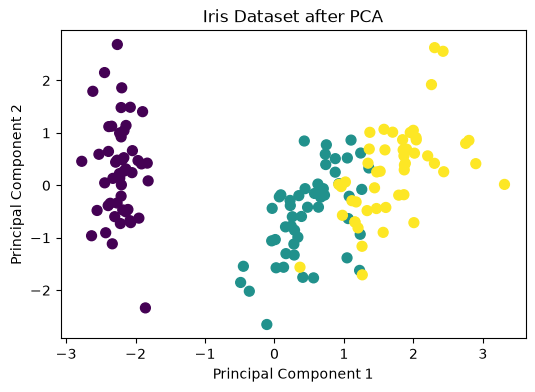

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset after PCA")

plt.show()

In [16]:
print(pca.components_)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


In [17]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

print("Explained Variance:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(explained_variance.cumsum())

Explained Variance:
[0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative Explained Variance:
[0.72962445 0.95813207 0.99482129 1.        ]


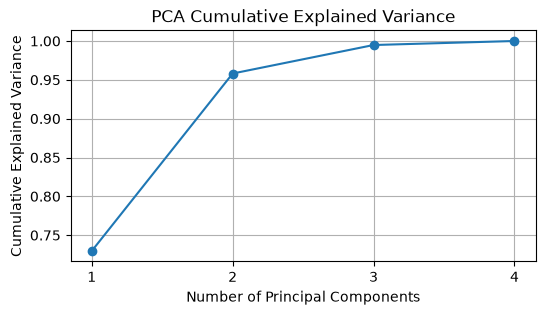

In [18]:
import matplotlib.pyplot as plt

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(6, 3))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.xticks(range(1, 5))
plt.grid()

plt.show()

In [24]:
pca_95 = PCA(
    n_components = 0.95
)

X_pca_95= pca_95.fit_transform(X_scaled)

print(X_pca_95.shape)
print(pca_95.explained_variance_ratio_)
print(pca_95.explained_variance_ratio_.sum())


(150, 2)
[0.72962445 0.22850762]
0.9581320720000166


In [25]:
# Can we go back from those 2 components to approximately the original 4 features? Yes
X_reconstructed = pca_95.inverse_transform(X_pca_95)

print(X_reconstructed.shape)

(150, 4)


In [27]:
# But they won't be exactly the same as X_scaled, because we discarded PC3 and PC4.
print("Original:")
print(X_scaled[:1])

print("\nReconstructed:")
print(X_reconstructed[:1])

Original:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]]

Reconstructed:
[[-0.99888895  1.05319838 -1.30270654 -1.24709825]]
